In [7]:
from PIL import Image
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.preprocessing import LabelBinarizer
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import RidgeClassifier
import xgboost as xgb
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG19
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import optimizers
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix
from tensorflow.keras.applications.vgg19 import preprocess_input

In [34]:
#Leitura dos dados extraídos do repositório
tab = pd.read_csv("./dados/train.csv", encoding='utf-8', low_memory=False)

In [35]:
tab["image"] = "dados\\" + tab["image"]
tab.head(3)

,image,band_count,ohms,tolerance,watts,bands
0,dados\4-band\4B-100K-T5\4B-100K-T5-1.jpg,4,100000.0,0.05,0.25,brown black yellow gold
1,dados\4-band\4B-100K-T5\4B-100K-T5-10.jpg,4,100000.0,0.05,0.25,brown black yellow gold
2,dados\4-band\4B-100K-T5\4B-100K-T5-2.jpg,4,100000.0,0.05,0.25,brown black yellow gold


In [36]:
tab.count()

image         1270
band_count    1270
ohms          1270
tolerance     1270
watts         1270
bands         1270
dtype: int64

In [37]:
l_encoder = LabelEncoder()

tab["label"] = l_encoder.fit_transform(tab["ohms"])

In [38]:
tab.head(3)

,image,band_count,ohms,tolerance,watts,bands,label
0,dados\4-band\4B-100K-T5\4B-100K-T5-1.jpg,4,100000.0,0.05,0.25,brown black yellow gold,72
1,dados\4-band\4B-100K-T5\4B-100K-T5-10.jpg,4,100000.0,0.05,0.25,brown black yellow gold,72
2,dados\4-band\4B-100K-T5\4B-100K-T5-2.jpg,4,100000.0,0.05,0.25,brown black yellow gold,72


In [39]:
#Função para converter imagem para array
def convert_image(image_to_convert):
  
  image_to_convert = image_to_convert.convert('RGB')
  #redimenciona imagem
  image_to_convert = image_to_convert.resize((224,224))
  image = np.asarray(image_to_convert, dtype=np.float32)

  image = preprocess_input(image)
  return np.asarray(image_to_convert)

In [40]:
def select_images(tab):
    imagens = []
    labels = []

    for _, row in tab.iterrows():
        print(1)
        image = Image.open(os.path.normpath(row["image"]))
        print(2)
        image = convert_image(image)
        print(3)
        imagens.append(image)
        print(4)
        labels.append(row["label"])
        print(5)
    return np.array(imagens), np.array(labels)

In [33]:
del tab

In [ ]:
imagens, labels = select_images(tab)


In [42]:
tab['Imagens'] = imagens

In [43]:
#Verificando quantidade de imagens para cada valor de resistência
tab.ohms.value_counts()

ohms
100000.0     20
270.0        20
2700.0       20
2200000.0    20
2.2          20
             ..
270000.0     10
12.0         10
12000.0      10
120000.0     10
9100.0       10
Name: count, Length: 89, dtype: int64

In [44]:
tab.ohms.nunique()

89

In [45]:
len(l_encoder.classes_)

89

In [46]:
#verificando se os tamnhos coincidem 
len(imagens), len(labels)

(1270, 1270)

In [13]:
labels

array([72, 72, 72, ..., 58, 58, 58])

In [47]:
#CALLBACKS
#São funções que podem ser passadas nos métodos do Keras para se integrar e auxiliar várias etapas do ciclo de vida do treinamento
#ModelCheckpoint: serve para salvar o modelo com uma certa frequência. Útil caso ocorra algum problema durante o processamento.
#https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/ModelCheckpoint
#ReduceLROnPlateau: Reduz a taxa de aprendizado quando alguma métrica para de melhorar com o avanço do treinamento. Muitos modelos se beneficiam ao reduzer a taa de aprendizado em 20%

from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping


In [48]:
#Definindo hiperparâmetros do modelo
batch_size   = 32
#Tamanho da imagem
input_shape  = (224, 224, 3)
#
random_state = 42
delta        = 1e-5
epoch        = 10

In [50]:
'''
path: onde será salvo o modelo
monitor: métrica a ser monitorada (acurácia)
verbose: (1) mostra na barra de progresso
save_best_only: Salvar somente o melhor modelo
mode: Queremos a máxima acurácia.
'''
###
path='resistors_transferlearning_weights.keras'
checkpoint = ModelCheckpoint(path, monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')

In [51]:

#monitor: valor observado (acurácia)
#factor: fator de redução
#min-delta: limiar para medir o novo ótimo, para focar apenas em mudanças significativas
#patience: número de épocas sem evolução do modelo
#verbose = 1: mostra mensagens de atualização
lr_reduce = ReduceLROnPlateau(monitor='val_accuracy', factor=0.2, min_delta=delta, patience=5, verbose=1)
e_stopping = EarlyStopping(monitor="val_loss",
    min_delta=delta,
    patience=3,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
    start_from_epoch=0,)
callbacks = [checkpoint, lr_reduce, e_stopping]

In [40]:
print(callbacks)

[<keras.src.callbacks.model_checkpoint.ModelCheckpoint object at 0x0000027BEF183590>, <keras.src.callbacks.reduce_lr_on_plateau.ReduceLROnPlateau object at 0x0000027BA2098BD0>]


In [52]:
#Separa em treino e teste numa proporção de 70/30
(x_train, x_test, y_train, y_test) = train_test_split(imagens, labels, test_size=0.30, stratify=labels, random_state=random_state)

In [19]:
print(y_train)
print(y_test)

[53 29 77  2 51 81 10 70 68  4 51 10  4 54 19 73 26 43 22 33 87 35 39 74
 20 42 41 65 32 76 66 35 60 58 25 70 67  9 49 41 53 43 53  6 26 26 34 44
 24 81 21 72 28 52 52 29 28 42  7 73 83 13  8 63 76 80 57 48 13 30  5 23
  4 44 38 46 87 68 51 37 25 18  6  0 77 62 80 76 49  3 60 57 12  6 49 44
 61  2 49 80  6 51 64 63 41 23 39 20 18 71 77 66 32 71 77 68 16 64 81 34
 10 17 55 44 44 18 28 71 42 81 85 11 42 87 21 29  6 46 28 30 88 32 48 11
 55 72 41 25 33  9 35 31 13 50 52  2 84 57 54 74 87 77 84 22 52 39 88 78
 26 73 22 13  9 67 87 86 40 80 54 77 80 43  0 66 26 38 47 53 23 87 31 21
 12 68 47 12 10 77 55 47 86 61 61 67 69 46 39 65 67 64  0 28 40 45 43 50
 20  9 84 69 82 10 13 11 49 43 22 53 81  9 14 65 10 74 25 39 88 37 42 22
  0  9 46 26 88 87 56 66 52 60 81  7 20 44 71 11  6 70 77 85 30 63 64 74
 82 75  9 53 72 20  6 64 87 21 16 44 22 31 58 39 36 51 42 47  2 45 20  4
 17 30 33 79  9 47 86  6 32 20 37 54 36 72 71 37 80  1 33 26 42 81 67 31
  1 65 23 45 68 35 84 69 68 60 83 15 50 27 59 56 74

In [57]:
from tensorflow.keras.applications.vgg19 import preprocess_input
'''
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    zoom_range=0.1
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)
'''
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=False
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)
#data_aug = val_datagen.flow(x_test, y_test, batch_size=batch_size)

train_generator = train_datagen.flow(
    x_train,
    y_train,
    batch_size=batch_size,
    shuffle=True
)

val_generator = val_datagen.flow(
    x_test,
    y_test,
    batch_size=batch_size,
    shuffle=False
)


In [30]:
#Data augmentation
#gera mais diversidade de dados, sem necessidade de fazer novas coletas
#train_datagen = ImageDataGenerator(
#        rotation_range=10,
#        zoom_range=0.1)

#data_aug = train_datagen.flow(x_train, y_train, batch_size=batch_size)

In [56]:
#transfer learning
#aproveita uma modelo treinado anteriormente
conv_base = VGG19(weights='imagenet', include_top=False, input_shape=input_shape)
conv_base.summary()

Model: "vgg19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,024,384 (76.39 MB)

 Trainable params: 20,024,384 (76.39 MB)

 Non-trainable params: 0 (0.00 B)

In [58]:
#Retreinando parte da VGG19
conv_base.trainable = True
set_trainable = False
for layer in conv_base.layers:
  if layer.name == 'block5_conv1':
    set_trainable = True
  if set_trainable:
    layer.trainable = True
  else:
    layer.trainable = False
#

conv_base.summary()

Model: "vgg19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,024,384 (76.39 MB)

 Trainable params: 9,439,232 (36.01 MB)

 Non-trainable params: 10,585,152 (40.38 MB)

In [59]:
#Instanciando modelo
    
num_classes = tab["label"].nunique()

model = models.Sequential([
    conv_base,

    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),

    layers.Dense(512, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(num_classes, activation="softmax")
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg19 (Functional)              │ ?                      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │   0 (unbuilt) │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,024,384 (76.39 MB)

 Trainable params: 9,439,232 (36.01 MB)

 Non-trainable params: 10,585,152 (40.38 MB)

In [56]:
del model

In [60]:
model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=["accuracy"])

In [63]:
'''
history = model.fit(
    data_aug,
    validation_data=(x_test, y_test),
    callbacks=callbacks,
    epochs=epoch
)
''' 
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epoch,
    callbacks=callbacks
)

Epoch 1/10


c:\Users\luiz.altimari\Documents\IA\cnn-resistors\dl-env\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.0197 - loss: 4.8243 
Epoch 1: val_accuracy improved from -inf to 0.01575, saving model to resistors_transferlearning_weights.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 412s 14s/step - accuracy: 0.0196 - loss: 4.8216 - val_accuracy: 0.0157 - val_loss: 9.4238 - learning_rate: 0.0010
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.0070 - loss: 4.6225
Epoch 2: val_accuracy improved from 0.01575 to 0.02100, saving model to resistors_transferlearning_weights.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 309s 11s/step - accuracy: 0.0071 - loss: 4.6225 - val_accuracy: 0.0210 - val_loss: 5.0743 - learning_rate: 0.0010
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.0148 - loss: 4.5397
Epoch 3: val_accuracy did not improve from 0.02100
28/28 ━━━━━━━━━━━━━━━━━━━━ 267s 9s/step - accuracy: 0.0147 - loss: 4.5406 - val_accuracy: 0.0157 - val_loss: 4.6250 - learning_rate: 0.0010
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.0

In [27]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg19 (Functional)              │ (None, 3, 3, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 89)             │        11,481 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,138,381 (149.30 MB)

 Trainable params: 9,517,401 (36.31 MB)

 Non-trainable params: 10,586,176 (40.38 MB)

 Optimizer params: 19,034,804 (72.61 MB)

In [64]:
history.history.keys()
print(max(history.history['accuracy']))
print(max(history.history['val_accuracy']))
print(max(history.history['loss']))
print(max(history.history['val_loss']))
print(max(history.history['learning_rate']))

0.02699662558734417
0.023622047156095505
4.747735500335693
9.423844337463379
0.0010000000474974513


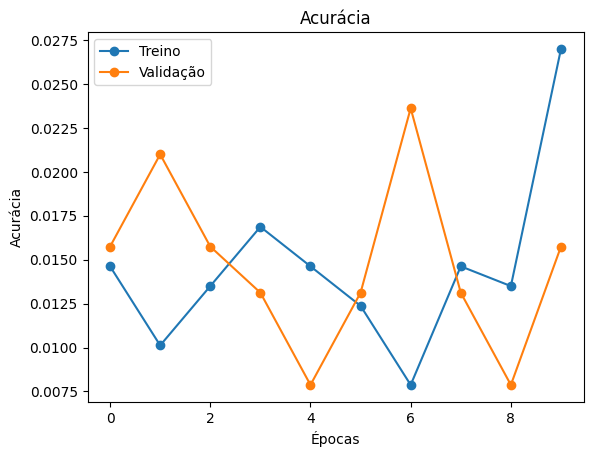

In [65]:

plt.plot(history.history['accuracy'], marker='o')
plt.plot(history.history['val_accuracy'], marker='o')
plt.title('Acurácia')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend(['Treino', 'Validação'])
plt.show()

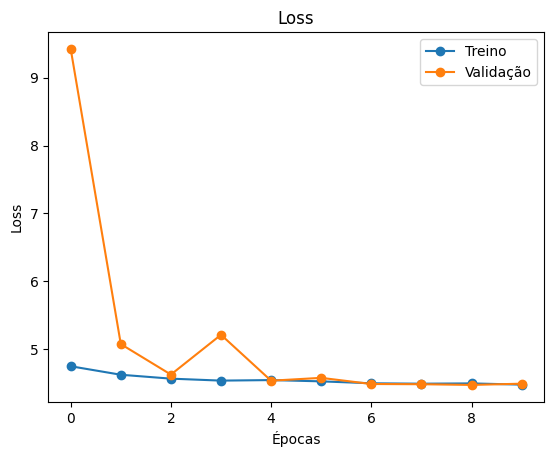

In [66]:
plt.plot(history.history['loss'], marker='o')
plt.plot(history.history['val_loss'], marker='o')
plt.title('Loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend(['Treino', 'Validação'])
plt.show()